# **Diferenças Finitas**

## **Aula 03 - Parte 0: introdução ao método**

## **Objetivo do notebook**

Antes de resolver os problemas de transferência de calor, vamos entender a ideia básica das diferenças finitas. O objetivo é substituir derivadas por combinações de valores da função em pontos vizinhos.

Neste notebook vamos:

- obter as aproximações a partir de séries de Taylor;
- comparar as fórmulas forward, backward e central;
- aplicar as fórmulas a derivadas de primeira e segunda ordem em 1D;
- estender a ideia para derivadas em 2D;
- visualizar malhas e observar o efeito da quantidade de pontos;
- montar um pequeno sistema linear para uma equação diferencial simples.

## **A ideia a partir da série de Taylor**

Considere uma função $f(x)$ e dois pontos próximos de $x_i$, separados por uma distância $h$. As expansões de Taylor são

$$
f(x_i+h) = f(x_i) + h f'(x_i) + \frac{h^2}{2}f''(x_i) + \mathcal{O}(h^3),
$$

e

$$
f(x_i-h) = f(x_i) - h f'(x_i) + \frac{h^2}{2}f''(x_i) + \mathcal{O}(h^3).
$$

As diferenças finitas surgem quando reorganizamos essas expressões para isolar as derivadas. O valor de $h$ é o espaçamento entre pontos consecutivos da malha.

## **Aproximações de primeira ordem**

Usando apenas o ponto atual e um ponto à frente, obtemos a diferença forward:

$$
f'(x_i) \approx \frac{f_{i+1}-f_i}{h}.
$$

Usando o ponto atual e um ponto atrás, obtemos a diferença backward:

$$
f'(x_i) \approx \frac{f_i-f_{i-1}}{h}.
$$

Combinando as duas expansões de Taylor, os termos de segunda ordem se cancelam e obtemos a diferença central:

$$
f'(x_i) \approx \frac{f_{i+1}-f_{i-1}}{2h}.
$$

A diferença central costuma ser mais precisa para pontos internos, pois utiliza informações dos dois lados do ponto $x_i$.

## **Aproximações de segunda ordem**

Para a segunda derivada, também podemos usar diferentes combinações de pontos:

$$
f''(x_i) \approx \frac{f_{i+2}-2f_{i+1}+f_i}{h^2}
\qquad \text{(forward)},
$$

$$
f''(x_i) \approx \frac{f_i-2f_{i-1}+f_{i-2}}{h^2}
\qquad \text{(backward)},
$$

e

$$
f''(x_i) \approx \frac{f_{i+1}-2f_i+f_{i-1}}{h^2}
\qquad \text{(central)}.
$$

De forma resumida, as fórmulas forward e backward possuem erro de truncamento da ordem de $h$, enquanto as fórmulas centrais apresentadas possuem erro da ordem de $h^2$. Isso significa que, ao reduzir o espaçamento, a aproximação central tende a melhorar mais rapidamente.

O stencil central de segunda ordem será especialmente importante para a equação de condução de calor, pois transforma derivadas espaciais em relações algébricas entre pontos vizinhos.

In [1]:
# Importando bibliotecas úteis
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)

## **Visualização de uma malha 1D**

Em uma malha uniforme, os pontos são definidos por $x_i=x_0+i h$. A escolha de $h$ determina quantos pontos serão usados para representar o intervalo.

Para calcular uma diferença central em $x_i$, por exemplo, precisamos dos pontos $x_{i-1}$, $x_i$ e $x_{i+1}$. Esse conjunto de pontos é chamado de stencil.

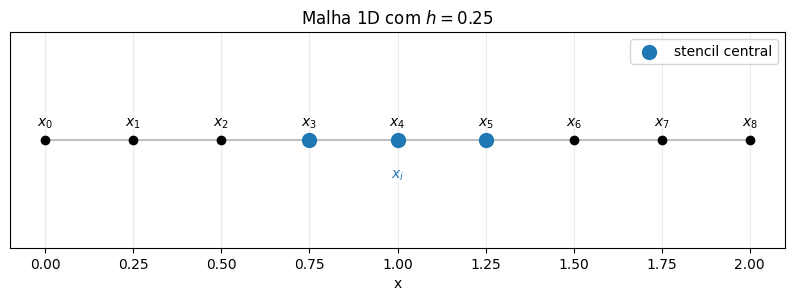

In [2]:
# Malha 1D e stencil central
x_malha = np.linspace(0, 2, 9)
h_malha = x_malha[1] - x_malha[0]

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(x_malha, np.zeros_like(x_malha), '-', color='0.75')
ax.scatter(x_malha, np.zeros_like(x_malha), color='black', zorder=3)

for i, xi in enumerate(x_malha):
    ax.annotate(f'$x_{i}$', (xi, 0), xytext=(0, 10),
                textcoords='offset points', ha='center')

i_central = 4
ax.scatter(x_malha[i_central-1:i_central+2],
           np.zeros(3), s=100, color='tab:blue', zorder=4,
           label='stencil central')
ax.annotate('$x_i$', (x_malha[i_central], 0), xytext=(0, -28),
            textcoords='offset points', ha='center', color='tab:blue')

ax.set_xlabel('x')
ax.set_yticks([])
ax.set_title(f'Malha 1D com $h={h_malha:.2f}$')
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='upper right')
plt.show()

## **Derivadas de primeira ordem em 1D**

Vamos usar a função matemática

$$
f(x)=\sin(x), \qquad f'(x)=\cos(x),
$$

para comparar as três aproximações. A função e sua derivada exata servem apenas como referência para visualizarmos o comportamento das diferenças finitas.

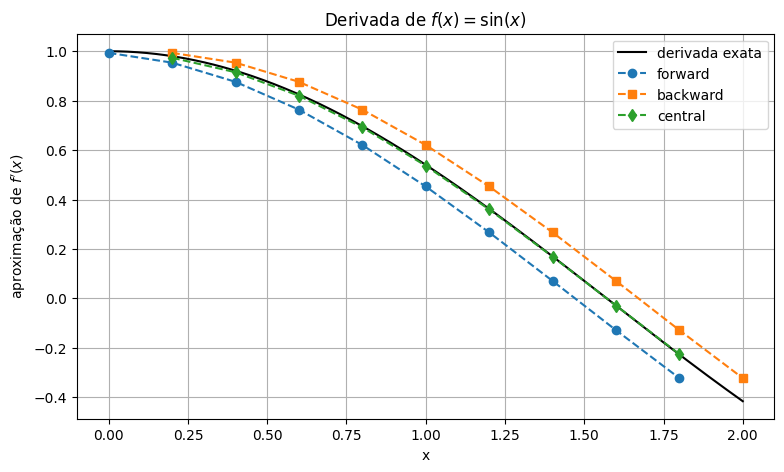

In [11]:
def primeira_forward(fun, x, h):
    return (fun(x + h) - fun(x)) / h


def primeira_backward(fun, x, h):
    return (fun(x) - fun(x - h)) / h


def primeira_central(fun, x, h):
    return (fun(x + h) - fun(x - h)) / (2 * h)


def primeira_por_malha(valores, h):
    forward = np.full_like(valores, np.nan, dtype=float)
    backward = np.full_like(valores, np.nan, dtype=float)
    central = np.full_like(valores, np.nan, dtype=float)

    forward[:-1] = (valores[1:] - valores[:-1]) / h
    backward[1:] = (valores[1:] - valores[:-1]) / h
    central[1:-1] = (valores[2:] - valores[:-2]) / (2 * h)

    return forward, backward, central


f = lambda x: np.sin(x)
df_exata = lambda x: np.cos(x)

x = np.linspace(0, 2, 11)
h = x[1] - x[0]
valores_f = f(x)
df_forward, df_backward, df_central = primeira_por_malha(valores_f, h)

x_continuo = np.linspace(0, 2, 400)

plt.figure(figsize=(9, 5))
plt.plot(x_continuo, df_exata(x_continuo), 'k-', label='derivada exata')
plt.plot(x, df_forward, 'o--', label='forward')
plt.plot(x, df_backward, 's--', label='backward')
plt.plot(x, df_central, 'd--', label='central')
plt.xlabel('x')
plt.ylabel("aproximação de $f'(x)$")
plt.title("Derivada de $f(x)=\\sin(x)$")
plt.grid(True)
plt.legend()
plt.show()

## **Derivadas de segunda ordem em 1D**

Para a mesma função, temos

$$
f''(x)=-\sin(x).
$$

Agora comparamos as aproximações forward, backward e central da segunda derivada.

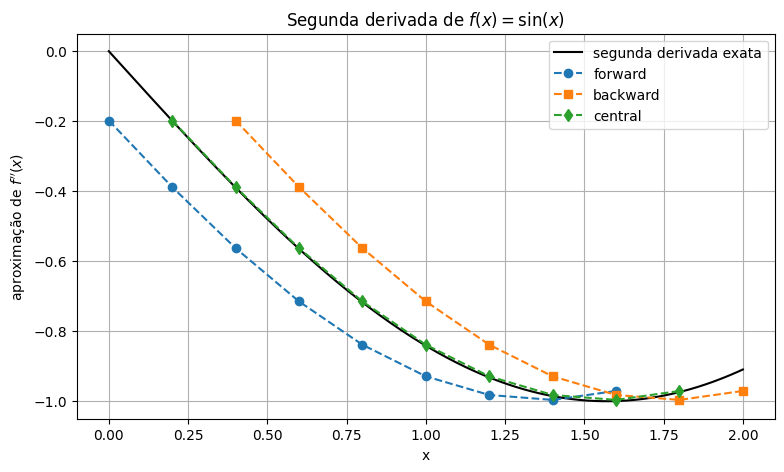

Ponto x0 = 1.0 e espaçamento h = 0.1
Segunda derivada exata: -0.84147098
Forward:                -0.89046493
Backward:               -0.78267435
Central:                -0.84076999


In [14]:
def segunda_forward(fun, x, h):
    return (fun(x + 2*h) - 2*fun(x + h) + fun(x)) / h**2


def segunda_backward(fun, x, h):
    return (fun(x) - 2*fun(x - h) + fun(x - 2*h)) / h**2


def segunda_central(fun, x, h):
    return (fun(x + h) - 2*fun(x) + fun(x - h)) / h**2


def segunda_por_malha(valores, h):
    forward = np.full_like(valores, np.nan, dtype=float)
    backward = np.full_like(valores, np.nan, dtype=float)
    central = np.full_like(valores, np.nan, dtype=float)

    forward[:-2] = (valores[2:] - 2*valores[1:-1] + valores[:-2]) / h**2
    backward[2:] = (valores[2:] - 2*valores[1:-1] + valores[:-2]) / h**2
    central[1:-1] = (valores[2:] - 2*valores[1:-1] + valores[:-2]) / h**2

    return forward, backward, central

x = np.linspace(0, 2, 11)
h = x[1] - x[0]
valores_f = f(x)

d2f_forward, d2f_backward, d2f_central = segunda_por_malha(valores_f, h)
d2f_exata = lambda x: -np.sin(x)

plt.figure(figsize=(9, 5))
plt.plot(x_continuo, d2f_exata(x_continuo), 'k-', label='segunda derivada exata')
plt.plot(x, d2f_forward, 'o--', label='forward')
plt.plot(x, d2f_backward, 's--', label='backward')
plt.plot(x, d2f_central, 'd--', label='central')
plt.xlabel('x')
plt.ylabel("aproximação de $f''(x)$")
plt.title("Segunda derivada de $f(x)=\\sin(x)$")
plt.grid(True)
plt.legend()
plt.show()

# Comparação numérica em um ponto interno
x0 = 1.0
h0 = 0.1
print(f"Ponto x0 = {x0} e espaçamento h = {h0}")
print(f"Segunda derivada exata: {d2f_exata(x0):.8f}")
print(f"Forward:                {segunda_forward(f, x0, h0):.8f}")
print(f"Backward:               {segunda_backward(f, x0, h0):.8f}")
print(f"Central:                {segunda_central(f, x0, h0):.8f}")

## **O efeito da quantidade de pontos em 1D**

Aumentar o número de pontos reduz o espaçamento $h$. Em geral, isso permite representar melhor a função e suas derivadas, mas também aumenta a quantidade de valores que precisam ser armazenados e calculados.

A seguir, a mesma derivada central é calculada com diferentes malhas.

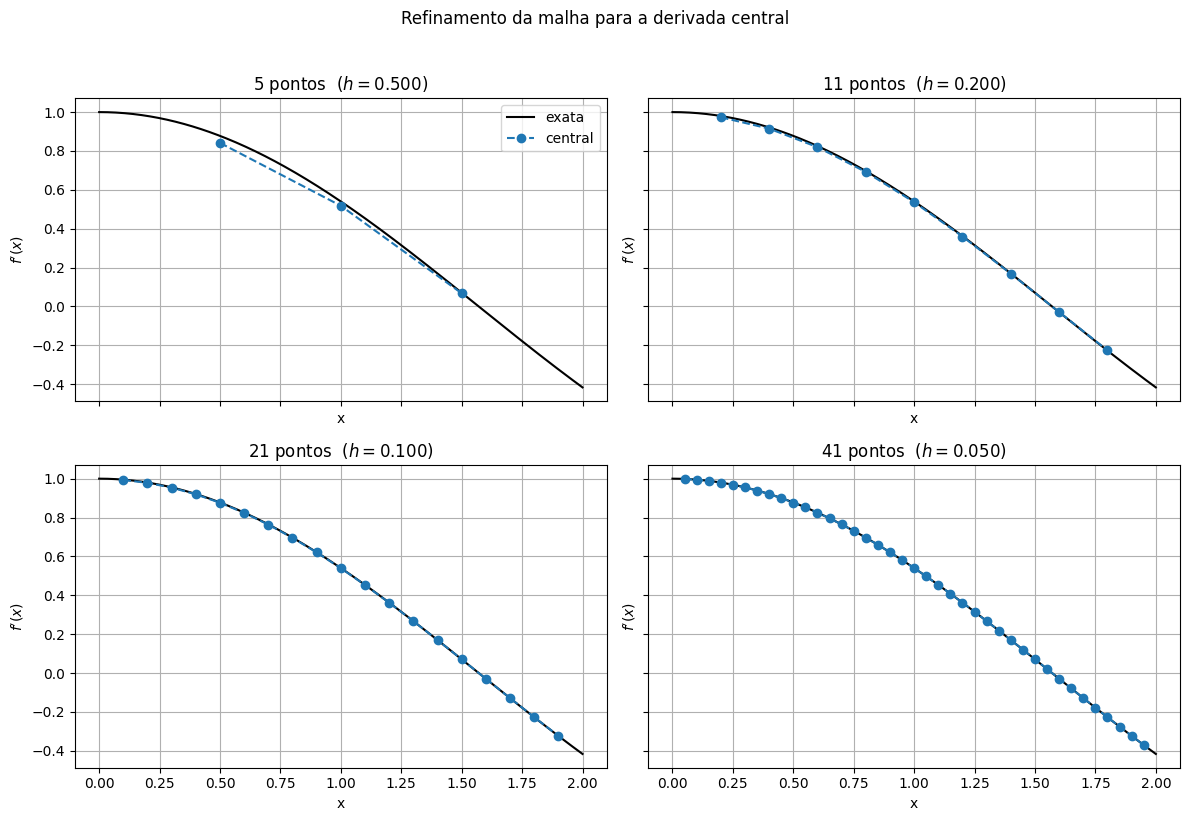

In [15]:
quantidades_de_pontos = [5, 11, 21, 41]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, n_pontos in zip(axes.ravel(), quantidades_de_pontos):
    x_m = np.linspace(0, 2, n_pontos)
    h_m = x_m[1] - x_m[0]
    valores = f(x_m)
    _, _, derivada_central = primeira_por_malha(valores, h_m)

    ax.plot(x_continuo, df_exata(x_continuo), 'k-', label='exata')
    ax.plot(x_m, derivada_central, 'o--', label='central')
    ax.set_title(f'{n_pontos} pontos  ($h={h_m:.3f}$)')
    ax.grid(True)
    ax.set_xlabel('x')
    ax.set_ylabel("$f'(x)$")

axes[0, 0].legend()
fig.suptitle('Refinamento da malha para a derivada central', y=1.02)
plt.tight_layout()
plt.show()

## **Extensão para duas dimensões**

Em uma malha 2D, cada ponto é identificado por dois índices: $x_i$ na direção horizontal e $y_j$ na direção vertical. As aproximações são aplicadas separadamente em cada direção:

$$
\frac{\partial f}{\partial x}\bigg|_{i,j}
\approx \frac{f_{i+1,j}-f_{i-1,j}}{2\Delta x},
\qquad
\frac{\partial f}{\partial y}\bigg|_{i,j}
\approx \frac{f_{i,j+1}-f_{i,j-1}}{2\Delta y}.
$$

Para as segundas derivadas:

$$
\frac{\partial^2 f}{\partial x^2}\bigg|_{i,j}
\approx \frac{f_{i+1,j}-2f_{i,j}+f_{i-1,j}}{\Delta x^2},
$$

$$
\frac{\partial^2 f}{\partial y^2}\bigg|_{i,j}
\approx \frac{f_{i,j+1}-2f_{i,j}+f_{i,j-1}}{\Delta y^2}.
$$

Portanto, a malha 2D usa pontos vizinhos na horizontal e na vertical. Nenhuma ideia nova é necessária: aplicamos a mesma aproximação 1D em cada coordenada.

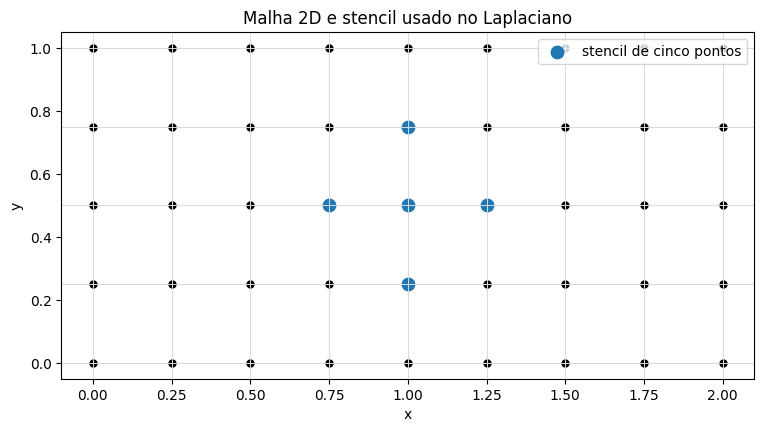

In [16]:
# Visualização de uma malha 2D
x_malha_2d = np.linspace(0, 2, 9)
y_malha_2d = np.linspace(0, 1, 5)
X_malha, Y_malha = np.meshgrid(x_malha_2d, y_malha_2d)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(X_malha, Y_malha, color='black', s=25)

for xi in x_malha_2d:
    ax.axvline(xi, color='0.85', lw=0.7)
for yi in y_malha_2d:
    ax.axhline(yi, color='0.85', lw=0.7)

# Ponto central e seus quatro vizinhos
i0 = len(x_malha_2d) // 2
j0 = len(y_malha_2d) // 2
vizinhos_x = [i0 - 1, i0, i0 + 1, i0, i0]
vizinhos_y = [j0, j0, j0, j0 - 1, j0 + 1]
ax.scatter(X_malha[vizinhos_y, vizinhos_x],
           Y_malha[vizinhos_y, vizinhos_x],
           color='tab:blue', s=80, label='stencil de cinco pontos')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Malha 2D e stencil usado no Laplaciano')
ax.set_aspect('equal')
ax.legend()
plt.show()

## **Derivadas de uma função em 2D**

Para verificar a implementação, considere

$$
f(x,y)=\sin(x)\cos(y).
$$

As derivadas exatas são

$$
f_x=\cos(x)\cos(y),
\qquad
f_y=-\sin(x)\sin(y),
$$

e o Laplaciano é

$$
\nabla^2 f=f_{xx}+f_{yy}=-2\sin(x)\cos(y).
$$

Vamos calcular essas quantidades usando diferenças centrais nos pontos internos da malha.

In [17]:
# Função e malha 2D
Nx = 41
Ny = 21
x2 = np.linspace(0, 2, Nx)
y2 = np.linspace(0, 1, Ny)
dx = x2[1] - x2[0]
dy = y2[1] - y2[0]
X2, Y2 = np.meshgrid(x2, y2)

F = np.sin(X2) * np.cos(Y2)

# Derivadas exatas
dfdx_exata = np.cos(X2) * np.cos(Y2)
dfdy_exata = -np.sin(X2) * np.sin(Y2)
laplaciano_exato = -2 * np.sin(X2) * np.cos(Y2)

# Arrays numéricos; as bordas permanecem como NaN porque o stencil central
# precisa de um ponto vizinho em cada lado.
dfdx_num = np.full_like(F, np.nan)
dfdy_num = np.full_like(F, np.nan)
laplaciano_num = np.full_like(F, np.nan)

dfdx_num[1:-1, 1:-1] = (F[1:-1, 2:] - F[1:-1, :-2]) / (2 * dx)
dfdy_num[1:-1, 1:-1] = (F[2:, 1:-1] - F[:-2, 1:-1]) / (2 * dy)

fxx_num = (F[1:-1, 2:] - 2 * F[1:-1, 1:-1] + F[1:-1, :-2]) / dx**2
fyy_num = (F[2:, 1:-1] - 2 * F[1:-1, 1:-1] + F[:-2, 1:-1]) / dy**2
laplaciano_num[1:-1, 1:-1] = fxx_num + fyy_num

# Comparação em um ponto interno
i_centro = Nx // 2
j_centro = Ny // 2
print(f'Ponto avaliado: (x, y) = ({x2[i_centro]:.2f}, {y2[j_centro]:.2f})')
print(f"df/dx exata e numérica: {dfdx_exata[j_centro, i_centro]:.8f} | {dfdx_num[j_centro, i_centro]:.8f}")
print(f"df/dy exata e numérica: {dfdy_exata[j_centro, i_centro]:.8f} | {dfdy_num[j_centro, i_centro]:.8f}")
print(f"Laplaciano exato e numérico: {laplaciano_exato[j_centro, i_centro]:.8f} | {laplaciano_num[j_centro, i_centro]:.8f}")

Ponto avaliado: (x, y) = (1.00, 0.50)
df/dx exata e numérica: 0.47415988 | 0.47396234
df/dy exata e numérica: -0.40342268 | -0.40325461
Laplaciano exato e numérico: -1.47692053 | -1.47661286


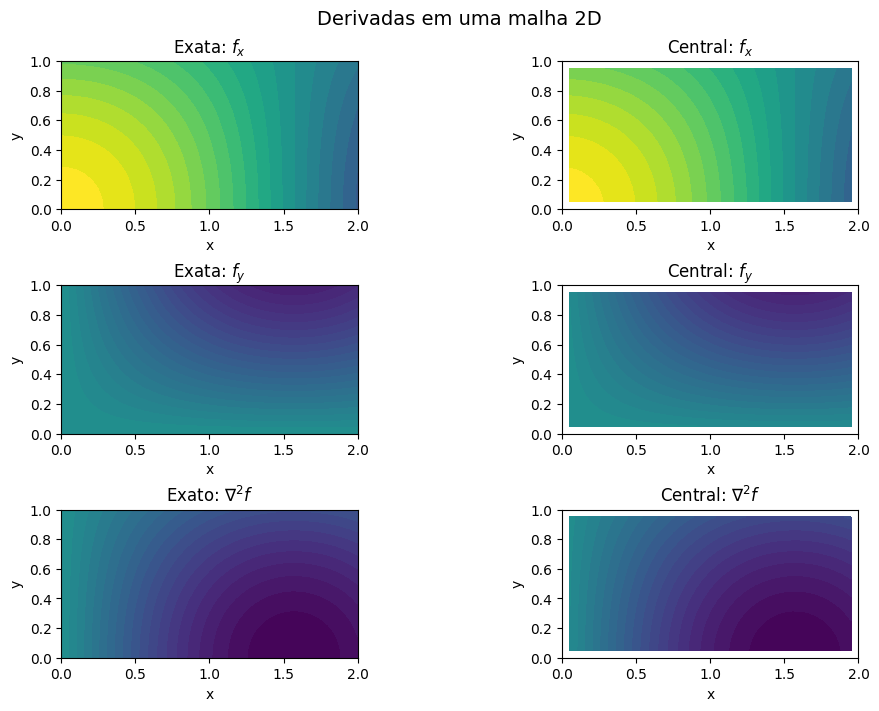

In [20]:
def desenhar_campo(ax, X, Y, campo, titulo, vmin=None, vmax=None):
    mapa = ax.contourf(X, Y, campo, levels=21, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    return mapa


fig, axes = plt.subplots(3, 2, figsize=(10, 7), constrained_layout=True)

limites_gradiente = (-1, 1)
desenhar_campo(axes[0, 0], X2, Y2, dfdx_exata, 'Exata: $f_x$', *limites_gradiente)
desenhar_campo(axes[0, 1], X2, Y2, dfdx_num, 'Central: $f_x$', *limites_gradiente)
desenhar_campo(axes[1, 0], X2, Y2, dfdy_exata, 'Exata: $f_y$', *limites_gradiente)
desenhar_campo(axes[1, 1], X2, Y2, dfdy_num, 'Central: $f_y$', *limites_gradiente)

limites_laplace = (-2, 2)
desenhar_campo(axes[2, 0], X2, Y2, laplaciano_exato, 'Exato: $\\nabla^2 f$', *limites_laplace)
desenhar_campo(axes[2, 1], X2, Y2, laplaciano_num, 'Central: $\\nabla^2 f$', *limites_laplace)

fig.suptitle('Derivadas em uma malha 2D', fontsize=14)
plt.show()

## **O stencil de cinco pontos**

Somando as duas aproximações centrais de segunda ordem, obtemos o Laplaciano discreto:

$$
\nabla^2 f_{i,j} \approx
\frac{f_{i+1,j}-2f_{i,j}+f_{i-1,j}}{\Delta x^2}
+
\frac{f_{i,j+1}-2f_{i,j}+f_{i,j-1}}{\Delta y^2}.
$$

Para uma malha uniforme, com $\Delta x=\Delta y=h$, a expressão fica

$$
\nabla^2 f_{i,j} \approx
\frac{f_{i+1,j}+f_{i-1,j}+f_{i,j+1}+f_{i,j-1}-4f_{i,j}}{h^2}.
$$

Esse é o stencil de cinco pontos: o valor central e os quatro vizinhos. É exatamente a estrutura usada na discretização 2D da equação de condução sem geração.

## **Da equação diferencial ao sistema linear**

Para visualizar como a discretização produz um problema numérico completo, considere o problema matemático

$$
u''(x)=-2, \qquad 0\leq x\leq 1,
$$

com

$$
u(0)=0, \qquad u(1)=0.
$$

A solução analítica é $u(x)=x(1-x)$. Aplicando a diferença central nos pontos internos:

$$
\frac{u_{i-1}-2u_i+u_{i+1}}{h^2}=-2.
$$

Cada ponto interno fornece uma equação. Juntando todas elas, obtemos um sistema linear $A\,u=b$.

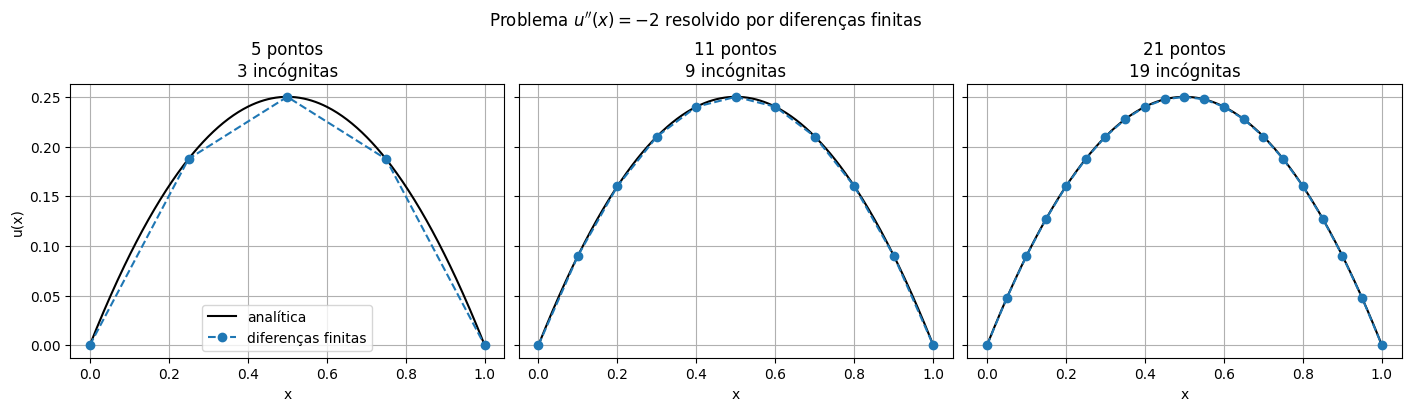

In [21]:
def resolver_problema_1d(n_pontos):
    x = np.linspace(0, 1, n_pontos)
    h = x[1] - x[0]
    n_internos = n_pontos - 2

    A = np.zeros((n_internos, n_internos))
    b = -2 * h**2 * np.ones(n_internos)

    for i in range(n_internos):
        A[i, i] = -2

        if i > 0:
            A[i, i - 1] = 1
        if i < n_internos - 1:
            A[i, i + 1] = 1

    u_interno = np.linalg.solve(A, b)
    u = np.zeros(n_pontos)
    u[1:-1] = u_interno
    return x, u


def solucao_exata_1d(x):
    return x * (1 - x)


quantidades_de_pontos = [5, 11, 21]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True,
                         constrained_layout=True)

x_exato = np.linspace(0, 1, 400)

for ax, n_pontos in zip(axes, quantidades_de_pontos):
    x_num, u_num = resolver_problema_1d(n_pontos)
    ax.plot(x_exato, solucao_exata_1d(x_exato), 'k-', label='analítica')
    ax.plot(x_num, u_num, 'o--', label='diferenças finitas')
    ax.set_title(f'{n_pontos} pontos\n{n_pontos - 2} incógnitas')
    ax.set_xlabel('x')
    ax.grid(True)

axes[0].set_ylabel('u(x)')
axes[0].legend()
fig.suptitle("Problema $u''(x)=-2$ resolvido por diferenças finitas")
plt.show()

## **Conclusão**

O método de diferenças finitas segue uma sequência simples:

1. definir uma malha de pontos;
2. escolher uma aproximação para cada derivada;
3. substituir as derivadas na equação diferencial;
4. aplicar as condições de contorno;
5. resolver os valores desconhecidos.

Nas próximas aulas, a mesma lógica será aplicada aos problemas de condução 1D, problemas transientes e problemas 2D. A principal diferença será a equação física e o tratamento das condições de contorno; a ideia de transformar derivadas em relações entre pontos vizinhos permanece a mesma.